# EDA and KPI

The data was downloaded from METABRIC in cBioPortal. The data contains 2509 female patients.

## Description of the data
1. One row = one patient (primary tumor sample)
2. No repeated measurements; each patient has exactly 1 sample
3. Target: Binary overall survival (0=living, 1=deceased)
4. Secondary target: Overall Survival (Months) for survival analysis

### Step 1: Data audit

In [153]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('brca_metabric/brca_metabric_clinical_data.tsv', sep='\t')

# Understand the columns
total = len(df)
audit_rows = []

for col in df.columns:
    n_unique = df[col].nunique() # Get total number of unique values in a column
    n_null = df[col].isna().sum() # Get the missing values per column
    pct_missing = (n_null / total)*100 
    pct_complete = (1 - n_null / total) * 100 # 1-null columns = percentage completeness of a column (feature)
    dtype = str(df[col].dtype) # Data type of each column
    top_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'N/A' # add most frequent value per column if mode is present else NA
    top_freq = df[col].value_counts().iloc[0] if n_unique > 0 else 0 # Get the frequency count per column

    audit_rows.append({
        'column': col,
        'dtype': dtype,
        'unique': n_unique,
        'non-null': total - n_null,
        'missing_pct': round(pct_missing,2),
        'completeness_pct': round(pct_complete, 2),
        'top_value': top_val,
        'top_freq': top_freq,
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.sort_values(by='missing_pct', ascending=False)

,column,dtype,unique,non-null,missing_pct,completeness_pct,top_value,top_freq
34,3-Gene classifier subtype,object,4,1764,29.69,70.31,ER+/HER2- Low Prolif,640
37,Tumor Stage,float64,5,1788,28.74,71.26,2.0,979
20,Primary Tumor Laterality,object,2,1870,25.47,74.53,Left,973
7,Cellularity,object,3,1917,23.60,76.40,High,965
4,Type of Breast Surgery,object,2,1955,22.08,77.92,MASTECTOMY,1170
19,Integrative Cluster,object,11,1980,21.08,78.92,8,299
14,HER2 status measured by SNP6,object,4,1980,21.08,78.92,NEUTRAL,1436
28,Radio Therapy,object,2,1980,21.08,78.92,YES,1173
27,PR Status,object,2,1980,21.08,78.92,Positive,1040
18,Inferred Menopausal State,object,2,1980,21.08,78.92,Post,1556


In [154]:
#Identify constant and near constant columns in the dataset
for _, row in audit_df.iterrows():
    if row['unique'] <= 1:
        print(f"Constant: {row['column']} → {row['top_value']}")
    elif row['unique'] == 2 and row['top_freq'] / total > 0.95:
        print(f"Near constant: {row['column']} → {row['top_value']} "
              f"({row['top_freq']}/{total} = {row['top_freq']/total*100:.1f}%)")
        
# Note that the fraction of instances covered under near constant feature was chosen \
# because if a feature values is same for the 95% of the instances then it can be assumed to be constant \
# If we use the fraction value of 0.7 then we get two near costant features namely \
# ER status measured by IHC (Positve (1817/2509 = 72.4%)) and ER Status (Positive (1825/2509 = 72.7%))

Constant: Study ID → brca_metabric
Constant: Cancer Type → Breast Cancer
Constant: Number of Samples Per Patient → 1
Constant: Sample Type → Primary
Constant: Sex → Female


- Since the number of patients per sample is constant, we should drop the column before processing further.

In [155]:
# Get the summary of numeric columns in the data
df_new = df.copy()
df_new = df_new.drop(columns=['Number of Samples Per Patient'], axis=1)
num_cols = df_new.select_dtypes(include=[np.number]).columns.tolist()
df_new[num_cols].describe().round(2)

,Age at Diagnosis,Cohort,Neoplasm Histologic Grade,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Relapse Free Status (Months),TMB (nonsynonymous),Tumor Size,Tumor Stage
count,2498.00,2498.00,2388.00,2243.00,2358.00,2287.00,1981.00,2388.00,2509.00,2360.00,1788.00
mean,60.42,2.90,2.41,1.95,5.59,4.03,125.24,110.29,6.85,26.22,1.71
std,13.03,1.96,0.65,4.02,3.99,1.19,76.11,77.54,5.32,15.37,0.66
min,21.93,1.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,50.92,1.00,2.00,0.00,3.00,3.05,60.87,41.10,3.92,17.00,1.00
50%,61.11,3.00,3.00,0.00,5.00,4.04,116.47,100.42,6.54,22.41,2.00
75%,70.00,4.00,3.00,2.00,7.00,5.04,185.13,169.87,9.15,30.00,2.00
max,96.29,9.00,3.00,45.00,81.00,7.20,355.20,389.33,104.60,182.00,4.00


In our project, Overall Survival (Months), Overall Survival Status, and Patient's Vital Status represent target variables, we need to understand values in these columns

In [156]:
# Understanding the target variables
# Overall survival status and patient vital status columns carry the same values

print(df_new['Overall Survival Status'].value_counts(dropna=False))

print(f"\nSurvival months range: ",
      f"{df_new['Overall Survival (Months)'].min():.1f} – ",f"{df_new['Overall Survival (Months)'].max():.1f}")
print(f"Median survival months: {df_new['Overall Survival (Months)'].median():.1f}")

Overall Survival Status
1:DECEASED    1144
0:LIVING       837
NaN            528
Name: count, dtype: int64

Survival months range:  0.0 –  355.2
Median survival months: 116.5


# Identify patients with missing data

In [157]:
# For the missingness analysis, we will make use of missingno package from pip
#!pip install missingno --no-cache-dir

# Load all the required python libraries
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Remember, we are using df_new moving forward. df_new was created by removing column: Number of Patients Per Sample

total = len(df_new) # total number of instances in the data

missing_per_column = df_new.isnull().sum() 

miss_pct = (missing_per_column / total * 100).round(2)

miss_df = pd.DataFrame({
    'Missing': missing_per_column.values,
    'Pct': round(miss_pct, 2)
}).sort_values('Pct', ascending=False)

miss_df

,Missing,Pct
3-Gene classifier subtype,745,29.69
Tumor Stage,721,28.74
Primary Tumor Laterality,639,25.47
Cellularity,592,23.60
Type of Breast Surgery,554,22.08
Integrative Cluster,529,21.08
HER2 status measured by SNP6,529,21.08
Radio Therapy,529,21.08
PR Status,529,21.08
Inferred Menopausal State,529,21.08


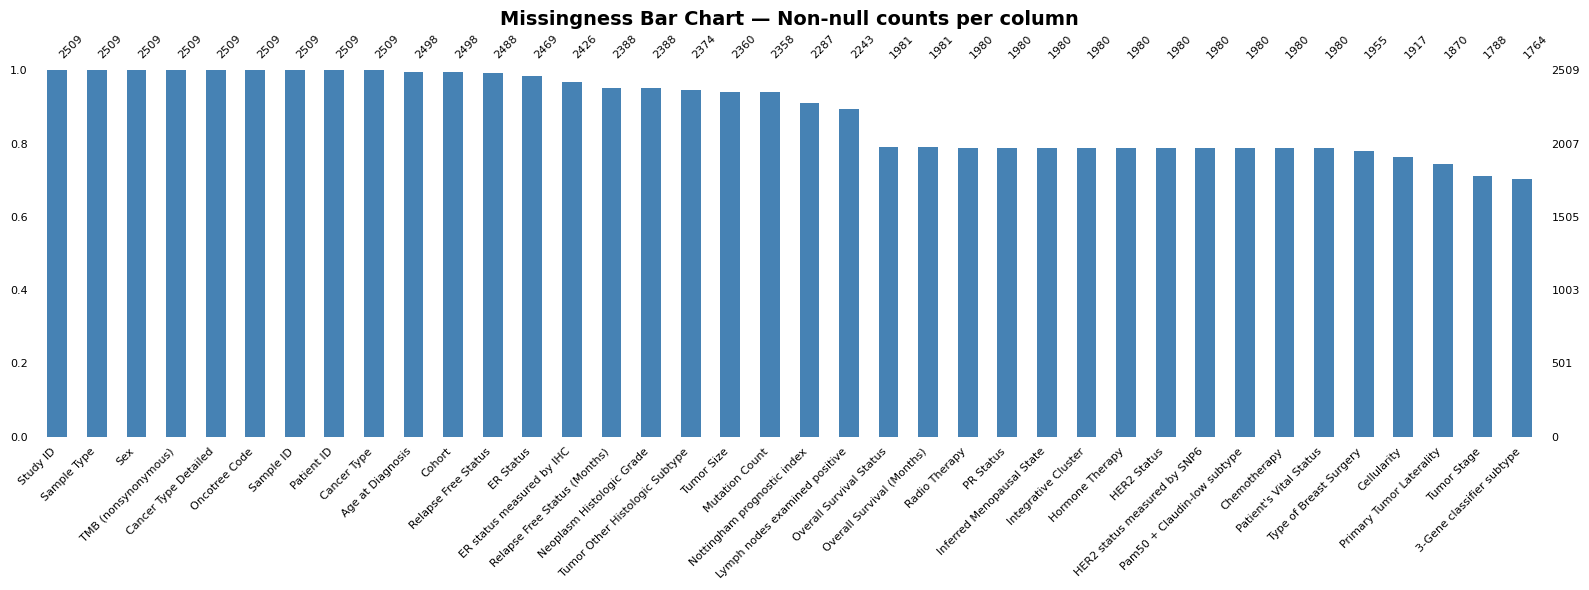

In [158]:
# columns ordered from fewest missing → most missing
# All the plots showing missignness will be shorted.

#1. Bar chart
cols_sorted = df_new.isnull().sum().sort_values().index
df_new = df_new[cols_sorted]

fig, ax = plt.subplots(figsize=(16, 6))
msno.bar(df_new, ax=ax, fontsize=8, color='steelblue')
ax.set_title('Missingness Bar Chart — Non-null counts per column', 
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
#plt.savefig('missingness_bar.png', dpi=150, bbox_inches='tight')

plt.close()

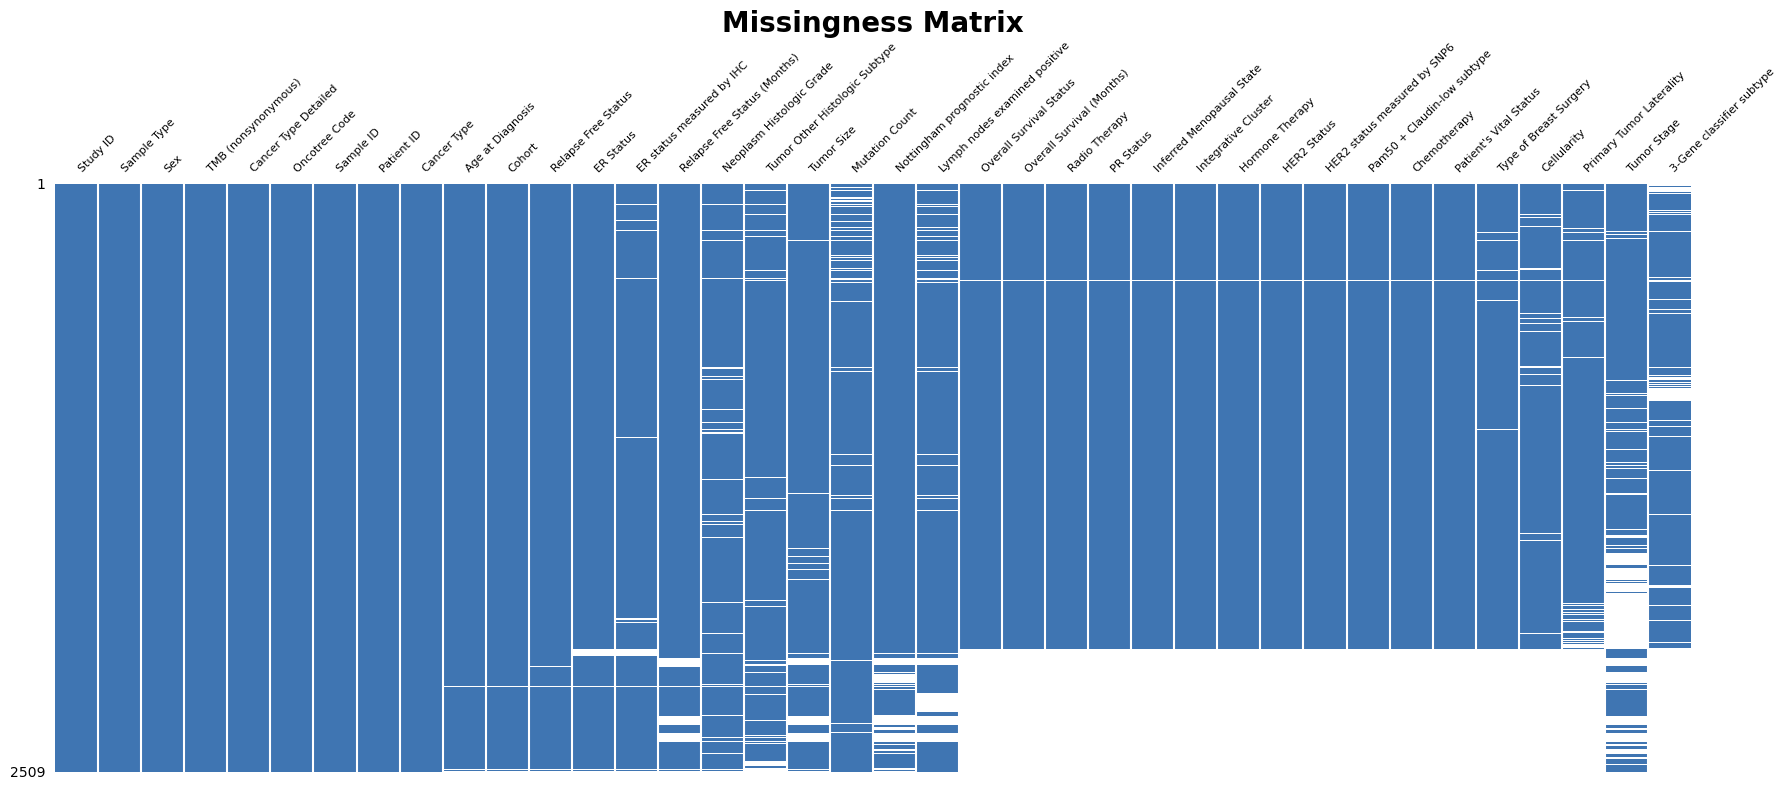


White is missingness



In [159]:
#2. Matrix
fig, ax = plt.subplots(figsize=(18, 8))
msno.matrix(df_new, ax=ax, fontsize=8, sparkline=False, color=(0.25, 0.46, 0.70))
ax.set_title('Missingness Matrix', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()
print(f'\nWhite is missingness\n')

Note: Nullity correlation shows how strongly the missingness of one column is related to the missingness of another column.

Empty cells in the heatmap represent features with no missing values.



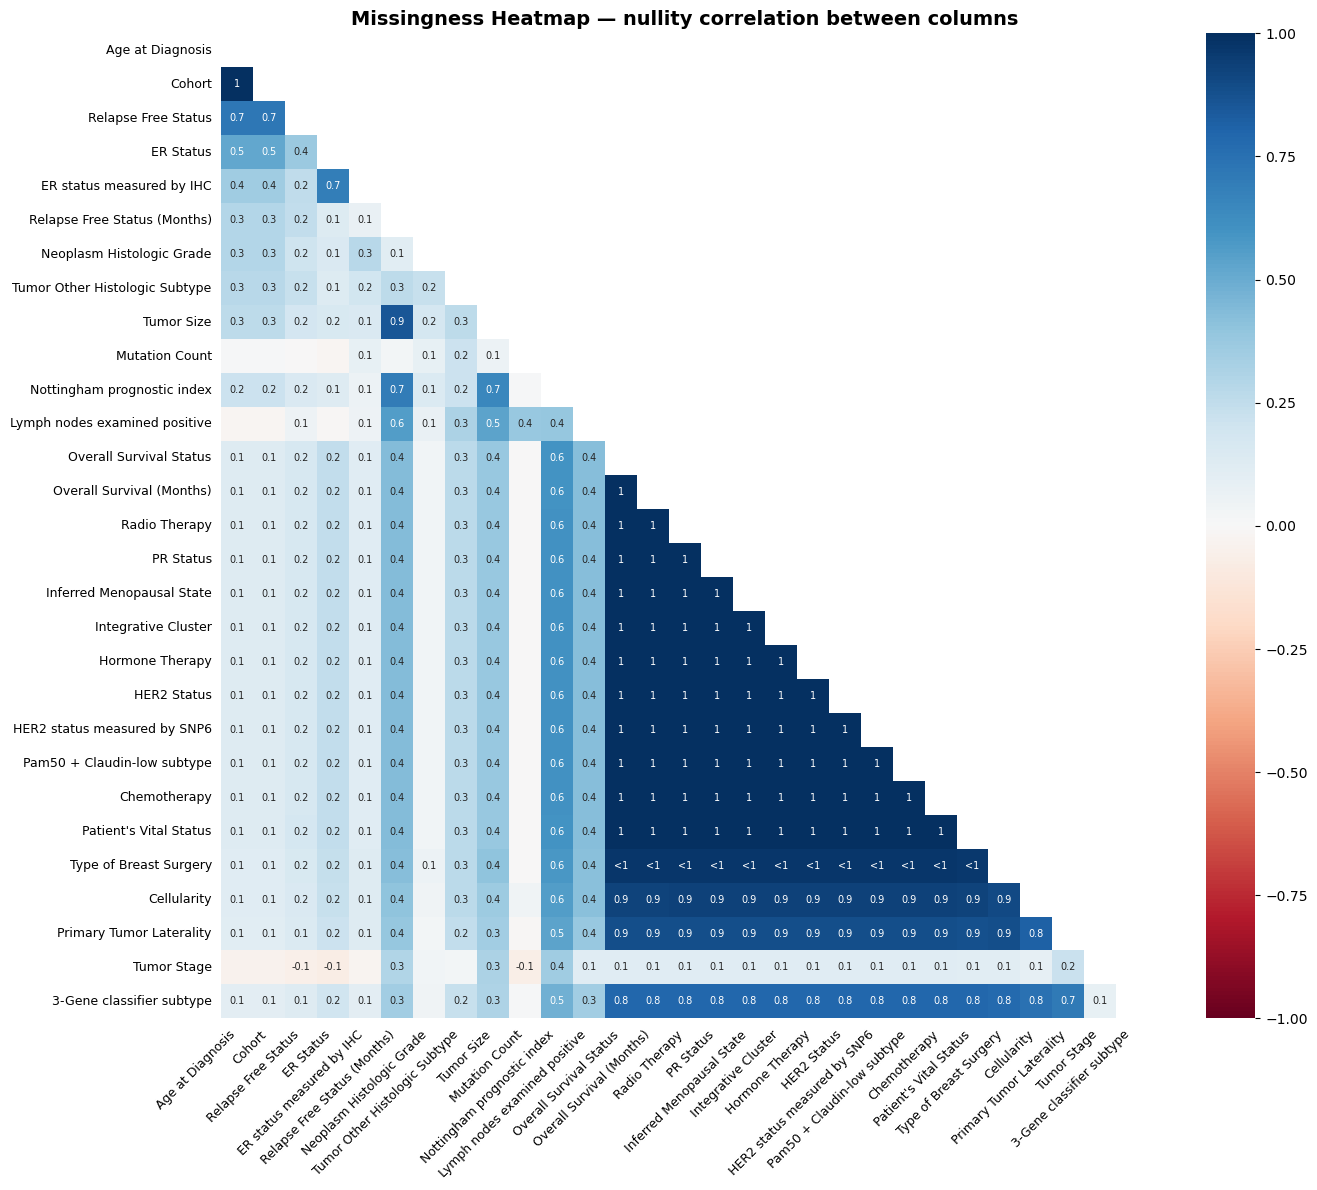

In [160]:
#Heatmap (nullity correlation)
print('Note: Nullity correlation shows how strongly the missingness of one column is related to the missingness of another column.\n')
print('Empty cells in the heatmap represent features with no missing values.\n')

fig, ax = plt.subplots(figsize=(14, 12))
msno.heatmap(df_new, ax=ax, fontsize=9)
ax.set_title('Missingness Heatmap — nullity correlation between columns',
    fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

plt.close()

Note: Columns that go missing together cluster together



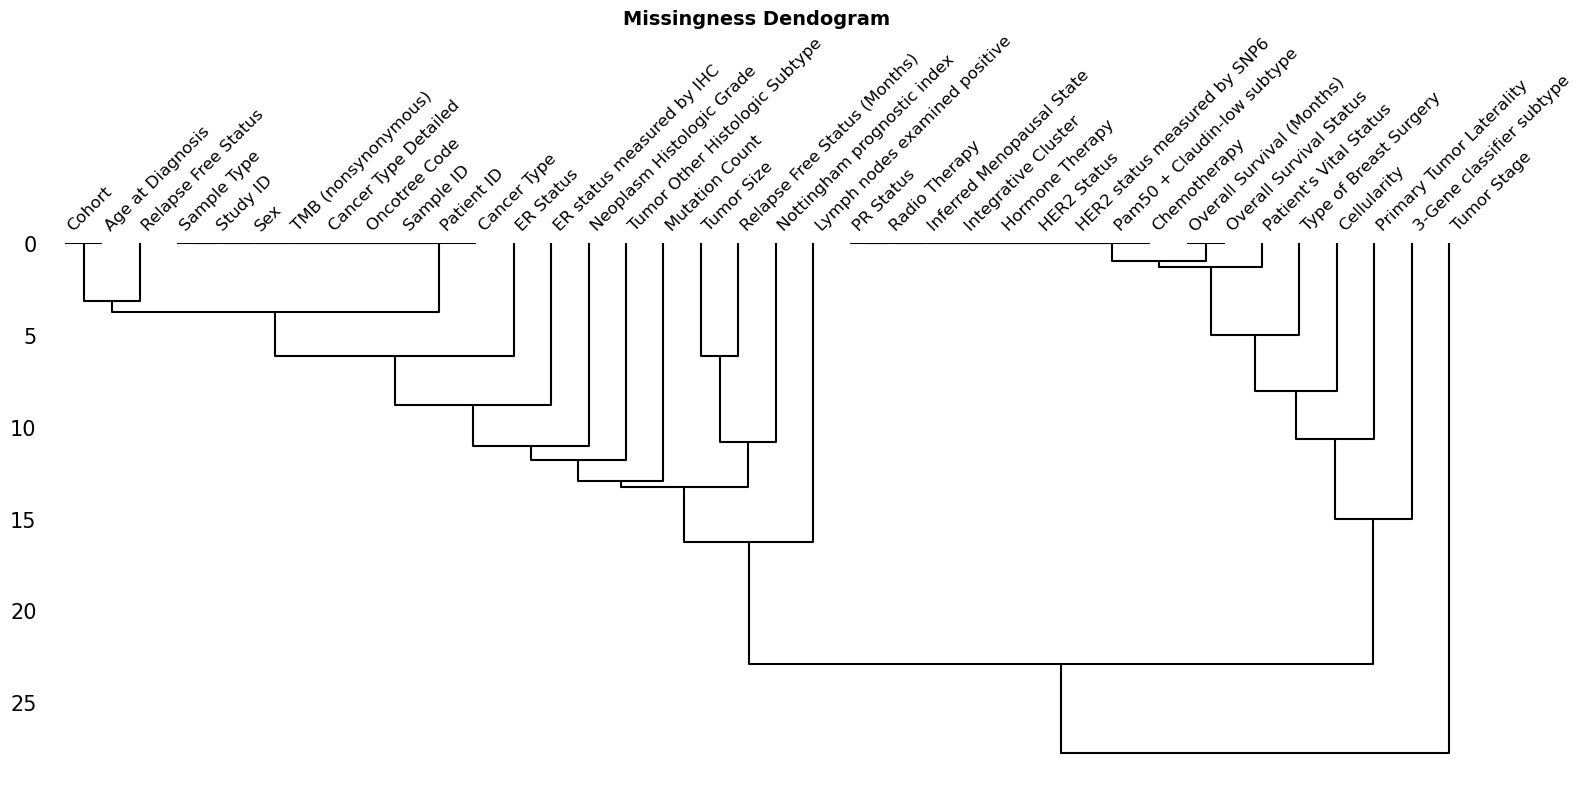

In [161]:
# 3. Dendogram (hierarchical clustering of missingness)
print('Note: Columns that go missing together cluster together\n')
fig, ax = plt.subplots(figsize=(16, 8))
msno.dendrogram(df_new, ax=ax, fontsize=12)

ax.set_title('Missingness Dendogram',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

#### Check if the missigness of the data is random or structured
- There are 529 patients for which Patient's Vital Status is missing
- Before moving on we need to check what are the features that have 529 missing values.

*Note: There are 528 patients for which **Overall Survial Status** and Months are unknown*

In [162]:
#Identify the features with 529 missing values

block_529 = miss_df[miss_df['Missing'] == 529].index.tolist()

print(f"Columns with exactly 529 missing values: {len(block_529)} columns\n")
for c in block_529:
    print(f"- {c}")

Columns with exactly 529 missing values: 10 columns

- Integrative Cluster
- HER2 status measured by SNP6
- Radio Therapy
- PR Status
- Inferred Menopausal State
- Hormone Therapy
- HER2 Status
- Patient's Vital Status
- Pam50 + Claudin-low subtype
- Chemotherapy


In [163]:
# Verify the missing columns in the dataset and find the if these are the same patients that have these missing values
null_masks = df[block_529].isnull()
all_same = null_masks.all(axis=1).sum()

print(f"\nPatients missing ALL {len(block_529)} columns: {all_same}")
print(f"Confirms these are the SAME {all_same} patients. Thus it shows that missingness is not random")


Patients missing ALL 10 columns: 528
Confirms these are the SAME 528 patients. Thus it shows that missingness is not random


*Note: As you can see above there are 528 patients with 10 missing columns, this is because we have 528 patients with missing overall status. Thus just 528 patients have the missing values*

Now the big question is: can we say anything about the survival of these 528 patients with missing values?
Since, there is no overall survial data for these patients, next best measure is relapse free status/months. Could the data be missing because the pateints recovered and did not come back for the further checkups?

In [164]:
# Who are the 529? Check if they share a cohort
print(f'Note: In this analysis, "Annotated patients" represents the data where the 10 columns are not missing\n')

block_patients = df_new[null_masks.all(axis=1)]
non_block = df_new[~null_masks.all(axis=1)]
print(f"529-block patients\nAge range: "
      f"{block_patients['Age at Diagnosis'].min():.0f}–"
      f"{block_patients['Age at Diagnosis'].max():.0f}\n")

print(f"Annotated patients\nAge range: "
      f"{non_block['Age at Diagnosis'].min():.0f}–"
      f"{non_block['Age at Diagnosis'].max():.0f}")

print("\nMISSINGNESS vs. SURVIVAL")
print("Question: Does being in the 529-block correlate with relapse status?\n")

# The 528 patients do have Relapse Free Status (99.2% complete)
print(f"529-block with their relapse rates:")
print(block_patients['Relapse Free Status'].value_counts(normalize=True).round(3)*100) # Count normalized without NAN values

print(f"\nAnnotated patients with their relapse rates:")
print(non_block['Relapse Free Status'].value_counts(normalize=True).round(3)*100)

Note: In this analysis, "Annotated patients" represents the data where the 10 columns are not missing

529-block patients
Age range: 27–89

Annotated patients
Age range: 22–96

MISSINGNESS vs. SURVIVAL
Question: Does being in the 529-block correlate with relapse status?

529-block with their relapse rates:
Relapse Free Status
0:Not Recurred    60.8
1:Recurred        39.2
Name: proportion, dtype: float64

Annotated patients with their relapse rates:
Relapse Free Status
0:Not Recurred    59.4
1:Recurred        40.6
Name: proportion, dtype: float64


As shown in the results above, patient age range and percentages of "Not Recurred" & "Recurred" remain comparable. The explanation for this could be because data for these pateints was missed due to administrative errors. In studies like METABRIC, the data comes from **patient registries** and even if a patient stops showing up for a hospital visit, their records get updated through this repo. The fact that treatment columns (Chemotherapy, Hormone Therapy, Radio Therapy) are also missing for the same patients further supports the administrative explanation. 

*Recommendations*: Thus, instances belonging patients with missing 10 columns should be dropped as this is not because the data was not randomly lost. 

In [165]:
print("\n\nSporadic/random missigness (data missing randomly from anywhere)")

sporadic_cols = miss_df[(miss_df['Missing'] > 0) & (miss_df['Missing'] != 529)].index.tolist()

print(f"Columns with sporadic or random missingness: {len(sporadic_cols)}")

for c in sporadic_cols:
    n = df_new[c].isna().sum()
    # Of the missing, how many are in the 529 patients block vs. sporadic?
    in_block = block_patients[c].isna().sum()
    out_block = non_block[c].isna().sum()
    print(f" - {c}: {n} missing total → {in_block} in missing patient block + {out_block} sporadic")



Sporadic/random missigness (data missing randomly from anywhere)
Columns with sporadic or random missingness: 19
 - 3-Gene classifier subtype: 745 missing total → 528 in missing patient block + 217 sporadic
 - Tumor Stage: 721 missing total → 206 in missing patient block + 515 sporadic
 - Primary Tumor Laterality: 639 missing total → 528 in missing patient block + 111 sporadic
 - Cellularity: 592 missing total → 528 in missing patient block + 64 sporadic
 - Type of Breast Surgery: 554 missing total → 528 in missing patient block + 26 sporadic
 - Overall Survival (Months): 528 missing total → 528 in missing patient block + 0 sporadic
 - Overall Survival Status: 528 missing total → 528 in missing patient block + 0 sporadic
 - Lymph nodes examined positive: 266 missing total → 190 in missing patient block + 76 sporadic
 - Nottingham prognostic index: 222 missing total → 221 in missing patient block + 1 sporadic
 - Mutation Count: 151 missing total → 30 in missing patient block + 121 spo

### METABRIC data imputation strategy summary

**Total patients:** 2,509 | **Block-missing patients:** 528 | **Annotated data:** 1,981

#### Imputation Decision Table

| Column | Sporadic Missing | Strategy | Recommendation |
|--------|:----------------:|----------|-----------|
| Overall Survival Status/Months | 0 | - | Target: never impute; Drop 528 patients |
| Relapse Free Status/Months | 0 | - | Keep as secondary target; not a feature |
| ER Status | 0 | No action | Complete in annotated cohort |
| Cohort & Age at Diagnosis | 0 | No action | Complete in annotated cohort |
| 3-Gene Classifier | 217 | - | Similar information as PAM50+ Claudin-low subtype; Further analysis needed |
| Tumor Stage | 515 | - | Similar information as NPI; Further analysis needed |
| ER status by IHC | 43 | Drop column | Duplicate of ER Status |
| Cellularity | 64 | Fill as "Unknown" | - |
| Surgery Type | 26 | Fill as "Unknown" | - |
| Laterality | 111 | Fill as "Unknown" | - |
| Histologic Subtype | 44 | Fill as "Unknown" | - |
| Histologic Grade | 88 | Mode within PAM50 group | Strong subtype–grade link |
| Mutation Count | 121 | Impute | - |
| Lymph Nodes Positive | 76 | Impute | - |
| Tumor Size | 26 | Impute | - |
| NPI | 1 | Recalculate from formula | NPI = 0.2 × tumor diameter + histological grade (1–3) + lymph node stage (1–3) |

In [166]:
# Object feature type subset
ob_nonblock = non_block.select_dtypes(include='object')

In [167]:
description = ob_nonblock.describe().T.reset_index()
print(f'List of object dtype columns with only 1 value: {description[description['unique']==1]['index'].tolist()}')
print(f'Remove before saving the dataset\n')

List of object dtype columns with only 1 value: ['Study ID', 'Sample Type', 'Sex', 'Cancer Type']
Remove before saving the dataset



In [168]:
# Remove columns recommended in previous step and save the annotated data
non_block = non_block.drop(columns=['Study ID', 'Sample Type', 'Sex', 'Cancer Type'])

In [169]:
# Get the numeric features
numeric_block = non_block.select_dtypes(include=['float', 'int', 'float16', 'float32', 'float64', 'int16', 'int32', 'int64'])
numeric_block.head()

,TMB (nonsynonymous),Age at Diagnosis,Cohort,Relapse Free Status (Months),Neoplasm Histologic Grade,Tumor Size,Mutation Count,Nottingham prognostic index,Lymph nodes examined positive,Overall Survival (Months),Tumor Stage
0,0.000000,75.65,1.0,140.500000,3.0,22.0,NaN,6.044,10.0,140.500000,2.0
1,2.615035,43.19,1.0,84.633333,3.0,10.0,2.0,4.020,0.0,84.633333,1.0
2,2.615035,48.87,1.0,153.300000,2.0,15.0,2.0,4.030,1.0,163.700000,2.0
3,1.307518,47.68,1.0,164.933333,2.0,25.0,1.0,4.050,3.0,164.933333,2.0
4,2.615035,76.97,1.0,18.800000,3.0,40.0,2.0,6.080,8.0,41.366667,2.0


In the numeric block, we can see that the mutation count has NAN values. METABRIC provides a raw data for each of the patients. Can we use this data to fill the missing values? 

- To check if we can do this directly from the raw data, we will plot distribution of **Mutation Count** in numeric block and the **Mutation Count** from the raw METABRIC data. If the distributions for both match then we can use raw data to safely fill the **Mutation Count**. 

In [170]:
# Load the mutation data from METABRIC
mutation = pd.read_csv('brca_metabric/data_mutations.txt', sep='\t', comment='#')
# In the dataset, Tumor_Sample_Barcode column has the patient IDs
# Beofore moving forward it is important to test how many genes (Hugo Symbols) per Patients in the mutation dataset

# Get counts per patient
counts = mutation['Tumor_Sample_Barcode'].value_counts()

# Patients with more than one mutation
multi_mut_patients = counts[counts > 1]
print(multi_mut_patients, '\n')

# Print the number of rows with missing mutation count value in our data
print(f'Number of patients with missing mutations: {non_block[non_block['Mutation Count'].isna()]['Patient ID'].nunique()}\n')

Tumor_Sample_Barcode
MB-5275      103
MB-4791       52
MB-4667       52
MTS-T1284     46
MB-4938       44
            ... 
MB-5251        2
MB-6014        2
MB-0341        2
MB-0621        2
MB-0308        2
Name: count, Length: 2259, dtype: int64 

Number of patients with missing mutations: 121



In [171]:
# Now match the patient ids with the patients with missing mutation values
# Since the patient ids are in the full annotated data, we will use that for this analysis
patients = non_block[non_block['Mutation Count'].isna()]['Patient ID'].tolist()
print(mutation[mutation.Tumor_Sample_Barcode.isin(patients)].Tumor_Sample_Barcode.value_counts())

print(f'This shows that out of {non_block[non_block['Mutation Count'].isna()]['Patient ID'].nunique()} patients, only 7 patients were found in mutation data\n')

Tumor_Sample_Barcode
MB-0142    2
MB-0573    2
MB-2634    2
MB-0424    1
MB-0606    1
MB-0641    1
MB-5420    1
Name: count, dtype: int64
This shows that out of 121 patients, only 7 patients were found in mutation data



In [172]:
patients_found_in_mutation = mutation[mutation.Tumor_Sample_Barcode.isin(patients)].Tumor_Sample_Barcode.value_counts().reset_index()
mutation_map = patients_found_in_mutation.set_index('Tumor_Sample_Barcode')['count']
mask = non_block['Patient ID'].isin(patients_found_in_mutation['Tumor_Sample_Barcode'])
non_block.loc[mask, 'Mutation Count'] = non_block.loc[mask, 'Patient ID'].map(mutation_map)

METABRIC also provided copy number variation (CNA) for the 22544 human genes. Copy number variations represent the number of increased or decreased copies of human genes. These variations in gene copies can lead to over expression of cancerous pathways. Thus, incorporating CNA might be useful for the predictive modeling. 

In [173]:
# Load the copy number variation data
cna = pd.read_csv('brca_metabric/data_cna.txt', sep='\t')
cna = cna.set_index(['Hugo_Symbol', 'Entrez_Gene_Id'])


In [174]:
print(f'Number of genes in CNA: {len(cna)}\n')
print(f'Number of genes after dropping missing cna: {len(cna.dropna())}: {round(len(cna.dropna())*100/len(cna), 2)}%\n')

Number of genes in CNA: 22544

Number of genes after dropping missing cna: 22079: 97.94%



Since after dropping missing values from the CNA, we still retain more than 97% of the human genes, we will collect CNA based on these >97% genes. 

In [175]:
# remove NAN from CNA data
cna = cna.dropna()

From METABRIC CNA metadata, we get copy number value annotation. Where, if -2 = homozygous deletion; -1 = hemizygous deletion; 0 = neutral/no change; 1 = gain; 2 = high level amplification.

In [176]:
labels = {-2: 'homdel', -1: 'hetloss', 0: 'neutral', 1: 'gain', 2: 'amp'}
counts = pd.DataFrame({labels[v]: (cna == v).sum(axis=0) for v in labels})

#Normalize the counts by number of genes
counts = round((counts/len(cna))*100, 3)

# Name the index so we can merge CNA with non_block based on this index
counts.index.name = 'Patient ID'
counts.head()

,homdel,hetloss,neutral,gain,amp
Patient ID,,,,,
MB-0000,0.000,0.018,99.855,0.127,0.000
MB-0039,0.009,8.827,90.425,0.485,0.254
MB-0045,1.409,28.244,59.708,8.528,2.111
MB-0046,0.027,22.021,69.926,3.460,4.565
MB-0048,0.050,12.510,67.195,18.185,2.061


In [177]:
merged = non_block.merge(counts, on='Patient ID', how='left')

# Now convert the overall survival months in the data into overall survial years
merged['Overall Survival (Years)'] = round(merged['Overall Survival (Months)']/12, 3)
merged.head()

,TMB (nonsynonymous),Cancer Type Detailed,Oncotree Code,Sample ID,Patient ID,Age at Diagnosis,Cohort,Relapse Free Status,ER Status,ER status measured by IHC,...,Cellularity,Primary Tumor Laterality,Tumor Stage,3-Gene classifier subtype,homdel,hetloss,neutral,gain,amp,Overall Survival (Years)
0,0.000000,Breast Invasive Ductal Carcinoma,IDC,MB-0000,MB-0000,75.65,1.0,0:Not Recurred,Positive,Positve,...,NaN,Right,2.0,ER-/HER2-,0.000,0.018,99.855,0.127,0.000,11.708
1,2.615035,Breast Invasive Ductal Carcinoma,IDC,MB-0002,MB-0002,43.19,1.0,0:Not Recurred,Positive,Positve,...,High,Right,1.0,ER+/HER2- High Prolif,0.761,25.631,68.038,4.452,1.119,7.053
2,2.615035,Breast Invasive Ductal Carcinoma,IDC,MB-0005,MB-0005,48.87,1.0,1:Recurred,Positive,Positve,...,High,Right,2.0,NaN,0.027,0.050,68.812,26.029,5.082,13.642
3,1.307518,Breast Mixed Ductal and Lobular Carcinoma,MDLC,MB-0006,MB-0006,47.68,1.0,0:Not Recurred,Positive,Positve,...,Moderate,Right,2.0,NaN,0.041,7.025,73.482,17.854,1.599,13.744
4,2.615035,Breast Mixed Ductal and Lobular Carcinoma,MDLC,MB-0008,MB-0008,76.97,1.0,1:Recurred,Positive,Positve,...,High,Right,2.0,ER+/HER2- High Prolif,0.050,11.418,82.907,3.696,1.929,3.447


Among the total 1981 instances in our dataset, there is 1 patient with missing Nottingham prognostic index (NPI).

We can re-calculate Nottingham prognostic index using following formula 
```NPI = 0.2 × tumor diameter (cm) + histological grade (1–3) + lymph node stage (1–3)```
from **A prognostic index in primary breast cancer. (PMID: 7073932)**

We can benchmark the calculations using the already available data in METABRIC.

In [ ]:
import numpy as np

def lymph_node_stage(n):
    if pd.isna(n):
        return np.nan
    if n == 0:
        return 1
    elif n <= 3:
        return 2
    else:  # >= 4
        return 3

merged['LN_Stage'] = merged['Lymph nodes examined positive'].apply(lymph_node_stage)

# Tumor Size is in mm in METABRIC which should be converted to cm (divided by 10)
merged['NPI_calc'] = np.floor(0.2 * df['Tumor Size'] / 10
    + merged['Neoplasm Histologic Grade']
    + merged['LN_Stage']).astype('Int64')

merged.head()

,TMB (nonsynonymous),Cancer Type Detailed,Oncotree Code,Sample ID,Patient ID,Age at Diagnosis,Cohort,Relapse Free Status,ER Status,ER status measured by IHC,...,Tumor Stage,3-Gene classifier subtype,homdel,hetloss,neutral,gain,amp,Overall Survival (Years),LN_Stage,NPI_calc
0,0.000000,Breast Invasive Ductal Carcinoma,IDC,MB-0000,MB-0000,75.65,1.0,0:Not Recurred,Positive,Positve,...,2.0,ER-/HER2-,0.000,0.018,99.855,0.127,0.000,11.708,3.0,6
1,2.615035,Breast Invasive Ductal Carcinoma,IDC,MB-0002,MB-0002,43.19,1.0,0:Not Recurred,Positive,Positve,...,1.0,ER+/HER2- High Prolif,0.761,25.631,68.038,4.452,1.119,7.053,1.0,4
2,2.615035,Breast Invasive Ductal Carcinoma,IDC,MB-0005,MB-0005,48.87,1.0,1:Recurred,Positive,Positve,...,2.0,NaN,0.027,0.050,68.812,26.029,5.082,13.642,2.0,4
3,1.307518,Breast Mixed Ductal and Lobular Carcinoma,MDLC,MB-0006,MB-0006,47.68,1.0,0:Not Recurred,Positive,Positve,...,2.0,NaN,0.041,7.025,73.482,17.854,1.599,13.744,2.0,4
4,2.615035,Breast Mixed Ductal and Lobular Carcinoma,MDLC,MB-0008,MB-0008,76.97,1.0,1:Recurred,Positive,Positve,...,2.0,ER+/HER2- High Prolif,0.050,11.418,82.907,3.696,1.929,3.447,3.0,6


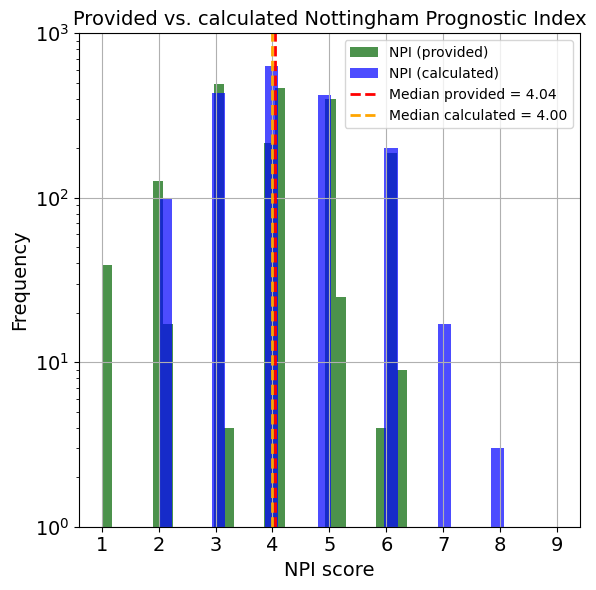

In [179]:
fig, ax = plt.subplots(figsize=(6, 6))

bins = 30  # shared bin count so they're comparable
merged['Nottingham prognostic index'].hist(
    ax=ax, bins=bins, alpha=0.7, label='NPI (provided)', color='darkgreen')

merged['NPI_calc'].hist(
    ax=ax, bins=bins, alpha=0.7, label='NPI (calculated)', color='blue')

# Median lines
median_provided = merged['Nottingham prognostic index'].median()
median_calc     = merged['NPI_calc'].median()
ax.axvline(median_provided, color='red', linestyle='--', linewidth=2,
           label=f'Median provided = {median_provided:.2f}')
ax.axvline(median_calc, color='orange', linestyle='--', linewidth=2,
           label=f'Median calculated = {median_calc:.2f}')

ax.set_xlabel('NPI score', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Provided vs. calculated Nottingham Prognostic Index', fontsize=14)
ax.legend()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xticks(range(1, 10))
plt.ylim(1, 1000)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [180]:
# Find rows where the provided NPI is missing
missing_idx = merged[merged['Nottingham prognostic index'].isna()].index
# Fill the value at the index
merged.loc[missing_idx, 'Nottingham prognostic index'] = merged.loc[missing_idx, 'NPI_calc']

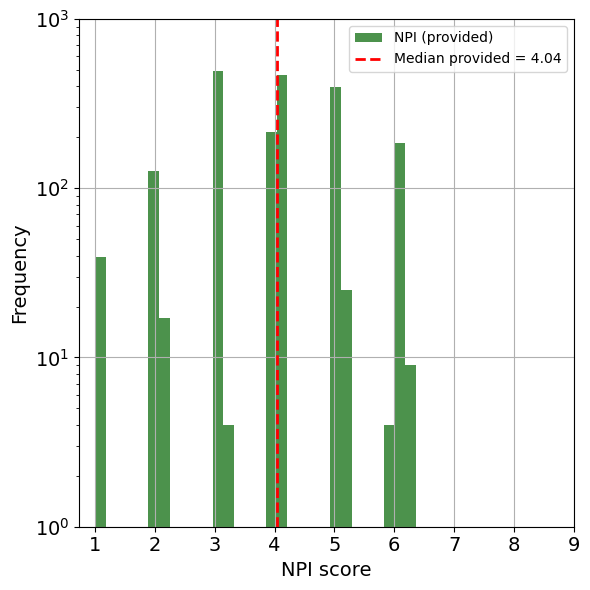

In [181]:
fig, ax = plt.subplots(figsize=(6, 6))

bins = 30  # shared bin count so they're comparable
merged['Nottingham prognostic index'].hist(
    ax=ax, bins=bins, alpha=0.7, label='NPI (provided)', color='darkgreen')

median_provided = merged['Nottingham prognostic index'].median()
ax.axvline(median_provided, color='red', linestyle='--', linewidth=2,
           label=f'Median provided = {median_provided:.2f}')

ax.set_xlabel('NPI score', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.legend()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xticks(range(1, 10))
plt.ylim(1, 1000)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
# Move 'Patient ID' and 'Sample ID' to the front
front = ['Patient ID', 'Sample ID']
merged = merged[front + [c for c in merged.columns if c not in front]]

# Merge with counts (which has Patient ID as its index)
merged.head()

,Patient ID,Sample ID,TMB (nonsynonymous),Cancer Type Detailed,Oncotree Code,Age at Diagnosis,Cohort,Relapse Free Status,ER Status,ER status measured by IHC,...,Tumor Stage,3-Gene classifier subtype,homdel,hetloss,neutral,gain,amp,Overall Survival (Years),LN_Stage,NPI_calc
0,MB-0000,MB-0000,0.000000,Breast Invasive Ductal Carcinoma,IDC,75.65,1.0,0:Not Recurred,Positive,Positve,...,2.0,ER-/HER2-,0.000,0.018,99.855,0.127,0.000,11.708,3.0,6
1,MB-0002,MB-0002,2.615035,Breast Invasive Ductal Carcinoma,IDC,43.19,1.0,0:Not Recurred,Positive,Positve,...,1.0,ER+/HER2- High Prolif,0.761,25.631,68.038,4.452,1.119,7.053,1.0,4
2,MB-0005,MB-0005,2.615035,Breast Invasive Ductal Carcinoma,IDC,48.87,1.0,1:Recurred,Positive,Positve,...,2.0,NaN,0.027,0.050,68.812,26.029,5.082,13.642,2.0,4
3,MB-0006,MB-0006,1.307518,Breast Mixed Ductal and Lobular Carcinoma,MDLC,47.68,1.0,0:Not Recurred,Positive,Positve,...,2.0,NaN,0.041,7.025,73.482,17.854,1.599,13.744,2.0,4
4,MB-0008,MB-0008,2.615035,Breast Mixed Ductal and Lobular Carcinoma,MDLC,76.97,1.0,1:Recurred,Positive,Positve,...,2.0,ER+/HER2- High Prolif,0.050,11.418,82.907,3.696,1.929,3.447,3.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1976,MB-7295,MB-7295,5.230071,Breast Invasive Lobular Carcinoma,ILC,43.10,4.0,0:Not Recurred,Positive,Positve,...,NaN,ER+/HER2- Low Prolif,0.005,2.509,92.581,4.842,0.063,16.406,2.0,6
1977,MB-7296,MB-7296,7.845106,Breast Invasive Ductal Carcinoma,IDC,42.88,4.0,1:Recurred,Positive,Positve,...,NaN,NaN,0.000,37.384,32.524,26.976,3.116,3.728,2.0,5
1978,MB-7297,MB-7297,5.230071,Breast Invasive Ductal Carcinoma,IDC,62.90,4.0,1:Recurred,Positive,Positve,...,NaN,NaN,0.009,20.087,64.699,9.606,5.598,14.664,3.0,6
1979,MB-7298,MB-7298,19.612766,Breast Invasive Ductal Carcinoma,IDC,61.16,4.0,0:Not Recurred,Positive,Positve,...,NaN,ER+/HER2- High Prolif,0.077,10.349,80.796,7.582,1.196,7.186,3.0,5


In [183]:
merged.to_csv('Final_metabric_data.tsv', sep='\t', index=False)

In [185]:
round(merged.describe(), 2)

,TMB (nonsynonymous),Age at Diagnosis,Cohort,Relapse Free Status (Months),Neoplasm Histologic Grade,Tumor Size,Mutation Count,Nottingham prognostic index,Lymph nodes examined positive,Overall Survival (Months),Tumor Stage,homdel,hetloss,neutral,gain,amp,Overall Survival (Years),LN_Stage,NPI_calc
count,1981.00,1981.00,1981.00,1981.00,1893.00,1955.00,1867.00,1981.00,1905.00,1981.00,1466.00,1981.00,1981.00,1981.00,1981.00,1981.00,1981.00,1905.00,1808.0
mean,6.99,61.09,2.62,111.54,2.41,26.28,5.70,4.01,2.00,125.24,1.74,0.08,15.43,73.06,8.68,2.75,10.44,1.64,4.14
std,5.44,12.95,1.23,77.33,0.65,15.38,4.08,1.16,4.08,76.11,0.64,0.31,13.54,19.10,7.75,2.61,6.34,0.74,1.11
min,0.00,21.93,1.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2.0
25%,3.92,51.42,1.00,42.30,2.00,17.00,3.00,3.04,0.00,60.87,1.00,0.00,4.24,61.95,3.16,0.16,5.07,1.00,3.0
50%,6.54,61.81,3.00,102.07,3.00,23.00,5.00,4.04,0.00,116.47,2.00,0.01,12.00,76.27,6.84,2.33,9.71,1.00,4.0
75%,9.15,70.60,3.00,169.83,3.00,30.00,7.00,5.04,2.00,185.13,2.00,0.04,23.94,87.67,12.00,4.72,15.43,2.00,5.0
max,104.60,96.29,5.00,351.00,3.00,182.00,81.00,6.36,45.00,355.20,4.00,6.60,63.51,100.00,52.36,14.26,29.60,3.00,9.0


### Insights
1. There are 1981 instances in the final dataset
2. After adding NPI values, there are no missing values in the dataset
3. After adding mutation counts for 7 patients now there are only 114 missing mutations
4. Added CNA percentages for each of the patients and there are no missing values in CNA columns
5. Converted target column (Overall Survival Months) to Overall Survial Years